# 01. ROSE and LROM for a Single Scattering Wavefunction

This notebook is the first end-to-end demonstration of the stateful
`lrom.LROM` API. It compares high-fidelity solutions of the nuclear
scattering equation with ROSE/RBM and LROM approximations for the
exact $l=0$ channel of $^{40}$Ca(n,n) at 14.1 MeV.

All horizontal axes use physical radius $r$ in fm. The LROM
calculations use the public v1.2 `lrom` package.
ROSE and LROM use the same high-fidelity training snapshots and retained rank,
but they use different reference functions: LROM is centered on the central
potential solution, while ROSE is centered on the free solution required by
its reduced-basis equations. Their reconstructed wavefunctions can be compared;
their coefficient values belong to different coordinate systems and are shown
separately.

## Notebook inputs

Two independent objects make the scientific distinction explicit:

- `vv_emulator`: `ws_1`, a Vv-only linspace study with normalized parameter predictors.
- `ws3_emulator`: `ws_3`, a Vv/Rv/av Latin-hypercube study with six selected potential predictors.

Both use a four-vector wavefunction basis and an eight-vector EIM basis.
Training and testing domains are deliberately separate so interpolation
and extrapolation behavior can be examined.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from numba import njit
import numpy as np
import pandas as pd

ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "lrom").is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for name in list(sys.modules):
    if name in ("lrom", "lrom_legacy") or name.startswith(("lrom.", "lrom_legacy.")):
        del sys.modules[name]

import scipy.special
if not hasattr(scipy.special, "sph_harm") and hasattr(scipy.special, "sph_harm_y"):
    # legacy sph_harm took (theta=azimuthal, phi=polar); sph_harm_y takes (polar, azimuthal)
    scipy.special.sph_harm = lambda m, n, theta, phi: scipy.special.sph_harm_y(n, m, phi, theta)

import rose
import lrom

BASIS_SIZE = 4
DISPLAY_ERROR_FLOOR = 1e-11
print("LROM package:", lrom.__version__)

@njit
def rose_real_woods_saxon(radius, alpha):
    # ROSE evaluates this exact callback for HF solves and builds its EIM from it.
    vv, rv, av = alpha
    return -vv / (1.0 + np.exp((radius - rv) / av))

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

LROM package: 1.2.0


## Section 1. Parameter Varying Vv

The first object isolates the effect of the real Woods-Saxon depth.
Its testing interval is wider than its training interval. The fixed
$R_v$ and $a_v$ values come from the Koning-Delaroche global
systematics for this target/projectile system at 14.1 MeV laboratory
energy; only $V_v$ varies in this teaching case.

In [2]:
vv_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_1",
)
vv_center = dict(vv_emulator.central_parameters)
Vv0 = vv_center["Vv"]
vv_training_ranges = {"Vv": (0.90 * Vv0, 1.10 * Vv0)}
vv_testing_ranges = {"Vv": (0.65 * Vv0, 1.35 * Vv0)}

# Public call: generate exact Runge-Kutta snapshots for the Vv design.
vv_emulator.sampling(
    training_ranges=vv_training_ranges,
    testing_ranges=vv_testing_ranges,
    training_size=35,
    testing_size=41,
    mesh_size=800,
    strategy="linspace",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)
# Public call: train RF-LROM with one normalized Vv predictor.
vv_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=1,
)

# LS is an explicit oracle benchmark: it projects the known testing
# wavefunctions onto the already-trained LROM basis.
vv_fom_test = vv_emulator.samples.testing_wavefunctions[0]
vv_ls_coefficients, vv_ls_wavefunctions = lrom.least_squares_baseline(
    basis=vv_emulator.basis[0],
    wavefunctions=vv_fom_test,
)
vv_ls_relative_l2 = lrom.relative_l2(
    prediction=vv_ls_wavefunctions,
    reference=vv_fom_test,
)

print("central parameters:", dict(vv_emulator.central_parameters))
print("Vv varies over the requested ranges")
print("fixed Rv [fm]:", vv_center["Rv"])
print("fixed av [fm]:", vv_center["av"])
print("training wavefunctions:", vv_emulator.samples.training_wavefunctions[0].shape)
print("testing wavefunctions:", vv_emulator.samples.testing_wavefunctions[0].shape)

# Following the ROSE tutorial, this notebook owns the EIM used only
# by the ROSE reduced equations. Package FOM sampling remains exact.
vv_central_row = np.asarray(
    [vv_center[name] for name in vv_emulator.parameter_names]
)
vv_rose_rows = np.vstack([
    vv_central_row,
    vv_emulator.samples.design.training.values,
    vv_emulator.samples.design.testing.values,
])
vv_rose_bounds = np.column_stack([
    vv_rose_rows.min(axis=0),
    vv_rose_rows.max(axis=0),
])
vv_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=len(vv_emulator.parameter_names),
    mu=vv_emulator.kinematics.mu,
    energy=vv_emulator.kinematics.e_com,
    is_complex=False,
    training_info=vv_rose_bounds,
    n_basis=8,
    rho_mesh=vv_emulator.samples.mesh.rho,
)
vv_rose_interaction = vv_rose_interactions.interactions[0][0]

# ROSE uses its free-solution reference and builds its own four-vector basis
# from the same high-fidelity training snapshots used by LROM.
vv_rose_phi0 = np.asarray([
    rose.free_solutions.phi_free(float(rho), 0, vv_emulator.kinematics.eta)
    for rho in vv_emulator.samples.mesh.rho
], dtype=np.complex128)
vv_rose_basis = rose.basis.CustomBasis(
    solutions=np.asarray(vv_emulator.samples.training_wavefunctions[0], dtype=np.complex128).T.copy(),
    phi_0=vv_rose_phi0.copy(),
    rho_mesh=vv_emulator.samples.mesh.rho,
    n_basis=BASIS_SIZE,
    solver=vv_emulator.full_order_model[0].solver,
    subtract_phi0=True,
    use_svd=True,
    center=False,
    scale=False,
)
vv_rose_rbe = rose.reduced_basis_emulator.ReducedBasisEmulator(
    vv_rose_interaction,
    vv_rose_basis,
    s_0=vv_emulator.full_order_model[0].base_solver.s_0,
    initialize_emulator=True,
)
vv_test_rows = vv_emulator.samples.design.testing.values
vv_rose_coefficients = np.asarray([vv_rose_rbe.coefficients(row) for row in vv_test_rows])
vv_rose_wavefunctions = np.asarray([vv_rose_rbe.emulate_wave_function(row) for row in vv_test_rows])

central parameters: {'Vv': 48.822175142383706, 'Rv': 4.053875273743491, 'av': 0.671852}
Vv varies over the requested ranges
fixed Rv [fm]: 4.053875273743491
fixed av [fm]: 0.671852
training wavefunctions: (35, 800)
testing wavefunctions: (41, 800)


The potential rainbow shows the isolated change in depth, while the
wavefunction rainbow shows the corresponding high-fidelity response.
Both panels use the same training cases and physical radius mesh.

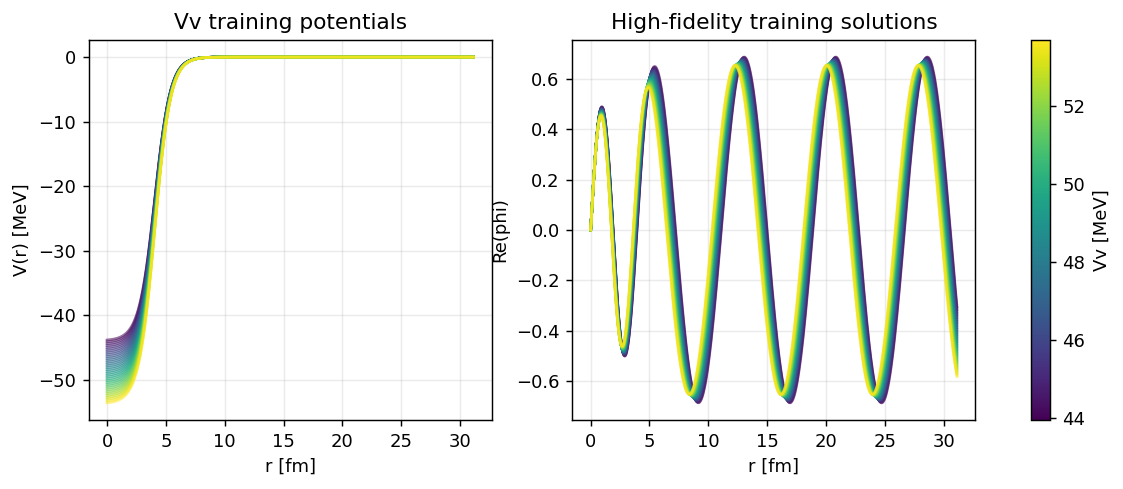

In [3]:
r = vv_emulator.mesh.radius
vv_values = vv_emulator.samples.design.training.values[:, 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
colors = plt.cm.viridis(np.linspace(0, 1, len(vv_values)))
for color, value, potential, phi in zip(
    colors,
    vv_values,
    vv_emulator.samples.training_potentials,
    vv_emulator.samples.training_wavefunctions[0],
):
    axes[0].plot(r, np.real(potential), color=color, alpha=0.55)
    axes[1].plot(r, np.real(phi), color=color, alpha=0.55)
axes[0].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="Vv training potentials")
axes[1].set(xlabel="r [fm]", ylabel="Re(phi)", title="High-fidelity training solutions")
fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vv_values.min(), vv_values.max()), cmap="viridis"
    ),
    ax=axes,
    label="Vv [MeV]",
)
plt.show()

The next figures show each method's basis beside its singular-value
decay, followed by coefficient trends. The spectra show whether four
retained vectors are consistent with the snapshot compression.

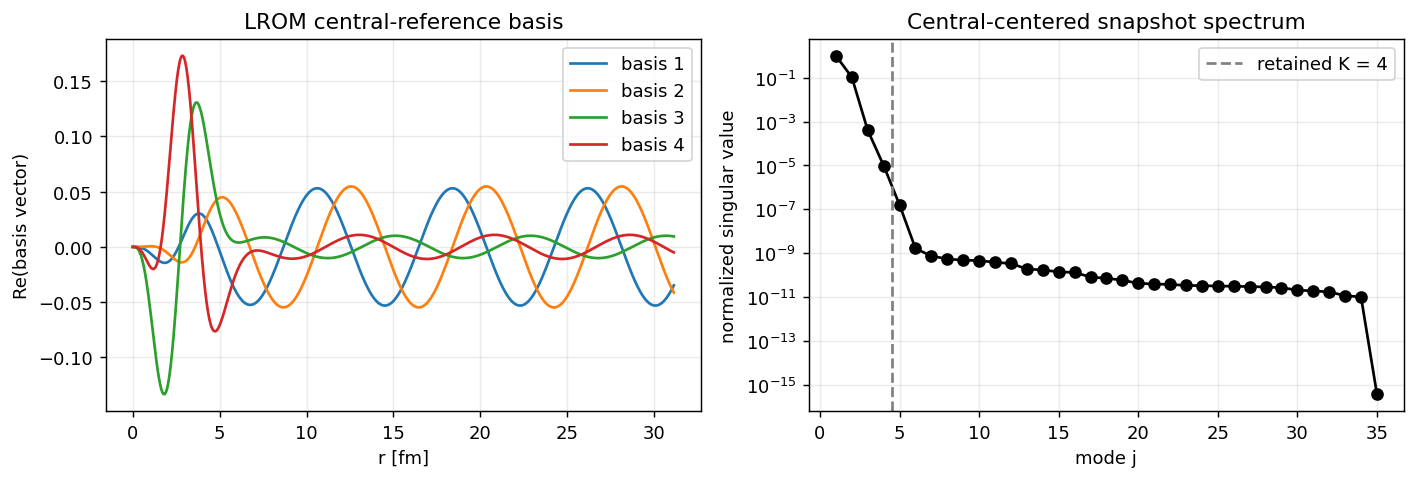

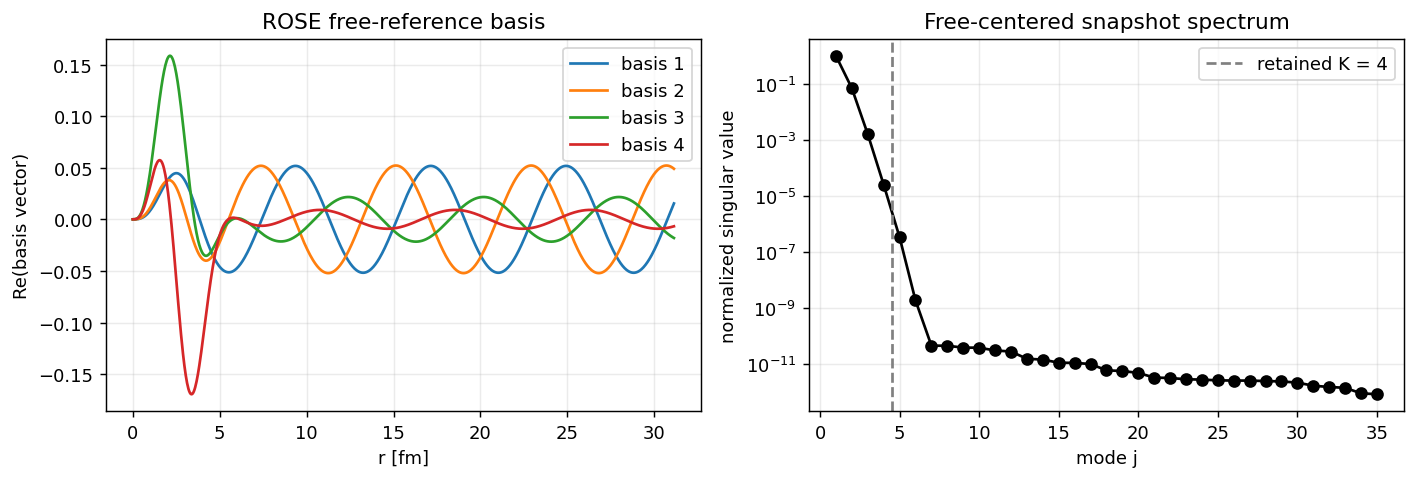

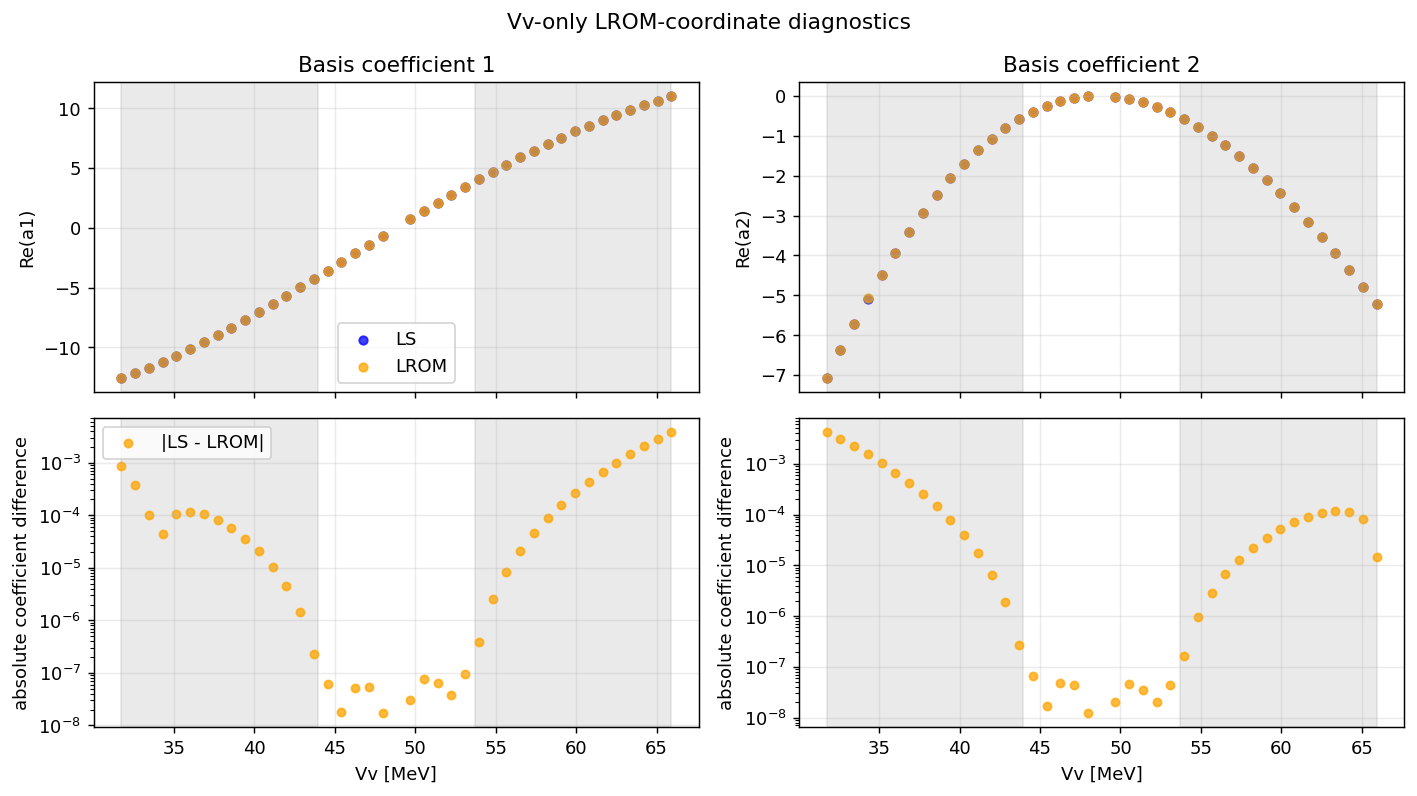

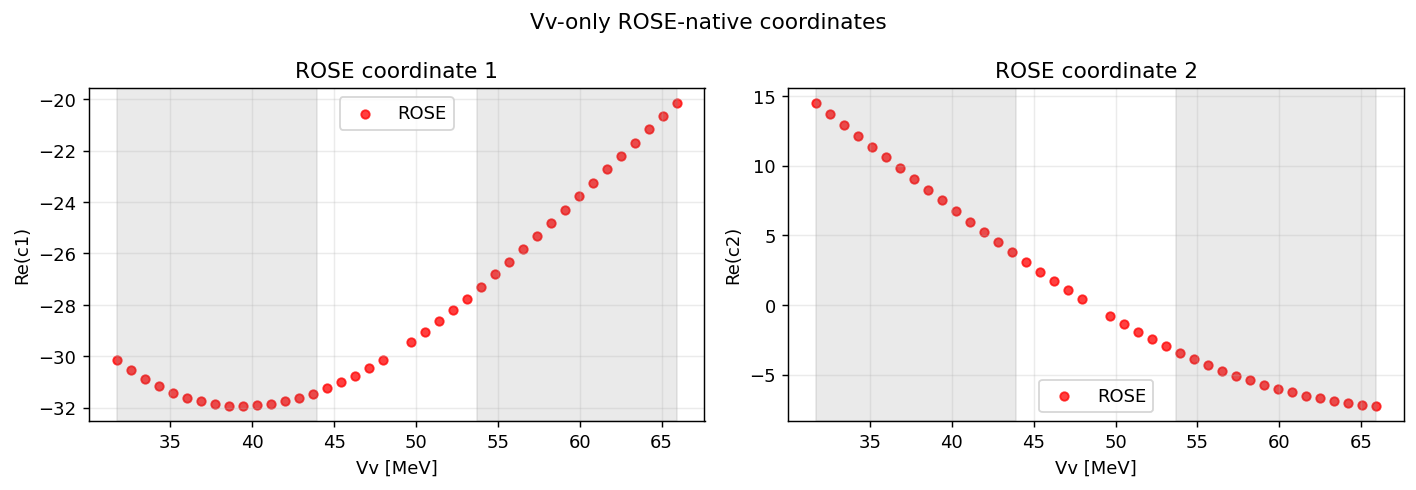

In [4]:
basis = vv_emulator.basis[0]
vv_lrom_centered_snapshots = (
    vv_emulator.samples.training_wavefunctions[0]
    - vv_emulator.samples.central_wavefunctions[0][None, :]
)
vv_lrom_singular_values = np.linalg.svd(
    vv_lrom_centered_snapshots, compute_uv=False
)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
for index in range(BASIS_SIZE):
    axes[0].plot(
        r,
        np.real(basis.vectors[:, index]),
        label=f"basis {index + 1}",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="LROM central-reference basis",
)
axes[0].legend()
vv_lrom_normalized_singular_values = (
    vv_lrom_singular_values / vv_lrom_singular_values[0]
)
vv_lrom_modes = np.arange(1, len(vv_lrom_normalized_singular_values) + 1)
axes[1].plot(
    vv_lrom_modes,
    vv_lrom_normalized_singular_values,
    "o-",
    color="black",
)
axes[1].axvline(
    BASIS_SIZE + 0.5,
    color="gray",
    linestyle="--",
    label="retained K = 4",
)
axes[1].set_yscale("log")
axes[1].set(
    xlabel="mode j",
    ylabel="normalized singular value",
    title="Central-centered snapshot spectrum",
)
axes[1].legend()
fig.tight_layout()
plt.show()

vv_rose_singular_values = np.asarray(vv_rose_basis.singular_values)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
for index in range(BASIS_SIZE):
    axes[0].plot(
        r,
        np.real(vv_rose_basis.vectors[:, index]),
        label=f"basis {index + 1}",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="ROSE free-reference basis",
)
axes[0].legend()
vv_rose_normalized_singular_values = (
    vv_rose_singular_values / vv_rose_singular_values[0]
)
vv_rose_modes = np.arange(1, len(vv_rose_normalized_singular_values) + 1)
axes[1].plot(
    vv_rose_modes,
    vv_rose_normalized_singular_values,
    "o-",
    color="black",
)
axes[1].axvline(
    BASIS_SIZE + 0.5,
    color="gray",
    linestyle="--",
    label="retained K = 4",
)
axes[1].set_yscale("log")
axes[1].set(
    xlabel="mode j",
    ylabel="normalized singular value",
    title="Free-centered snapshot spectrum",
)
axes[1].legend()
fig.tight_layout()
plt.show()

vv_test = vv_emulator.samples.design.testing.values[:, 0]
vv_plot_mask = ~np.isclose(vv_test, Vv0, rtol=0.0, atol=1e-12)
coefficients = {
    "ls": {0: vv_ls_coefficients},
    "lrom": dict(vv_emulator.testing_results.coefficients["lrom"]),
}
vv_train_low, vv_train_high = vv_training_ranges["Vv"]
fig, axes = plt.subplots(2, 2, figsize=(11.0, 6.2), sharex="col")
for coefficient_index in range(2):
    ax = axes[0, coefficient_index]
    difference_ax = axes[1, coefficient_index]
    for method, color in (("ls", "blue"), ("lrom", "orange")):
        ax.scatter(
            vv_test[vv_plot_mask],
            np.real(coefficients[method][0][vv_plot_mask, coefficient_index]),
            s=22,
            color=color,
            alpha=0.75,
            label=method.upper(),
        )
    ax.axvspan(vv_test.min(), vv_train_low, color="gray", alpha=0.16)
    ax.axvspan(vv_train_high, vv_test.max(), color="gray", alpha=0.16)
    difference_ax.axvspan(vv_test.min(), vv_train_low, color="gray", alpha=0.16)
    difference_ax.axvspan(vv_train_high, vv_test.max(), color="gray", alpha=0.16)
    ls_coefficients = np.real(coefficients["ls"][0][:, coefficient_index])
    lrom_coefficients = np.real(coefficients["lrom"][0][:, coefficient_index])
    difference_ax.scatter(
        vv_test[vv_plot_mask],
        np.maximum(
            np.abs(ls_coefficients - lrom_coefficients)[vv_plot_mask],
            DISPLAY_ERROR_FLOOR,
        ),
        s=20,
        color="orange",
        alpha=0.75,
        label="|LS - LROM|",
    )
    ax.set_ylabel(f"Re(a{coefficient_index + 1})")
    ax.set_title(f"Basis coefficient {coefficient_index + 1}")
    difference_ax.set_yscale("log")
    difference_ax.set_xlabel("Vv [MeV]")
    difference_ax.set_ylabel("absolute coefficient difference")
axes[0, 0].legend()
axes[1, 0].legend()
fig.suptitle("Vv-only LROM-coordinate diagnostics")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), sharex=True)
for coefficient_index, ax in enumerate(axes):
    ax.scatter(
        vv_test[vv_plot_mask],
        np.real(vv_rose_coefficients[vv_plot_mask, coefficient_index]),
        s=22,
        color="red",
        alpha=0.75,
        label="ROSE",
    )
    ax.axvspan(vv_test.min(), vv_train_low, color="gray", alpha=0.16)
    ax.axvspan(vv_train_high, vv_test.max(), color="gray", alpha=0.16)
    ax.set(
        xlabel="Vv [MeV]",
        ylabel=f"Re(c{coefficient_index + 1})",
        title=f"ROSE coordinate {coefficient_index + 1}",
    )
    ax.legend()
fig.suptitle("Vv-only ROSE-native coordinates")
fig.tight_layout()
plt.show()

A noncentral test case avoids the exact central-reference overlap and
gives a visible wavefunction comparison for all three methods.

selected noncentral Vv testing case: test-0021 {'Vv': 49.67656320737542, 'Rv': 4.053875273743491, 'av': 0.671852}
distance from central Vv [MeV]: 0.854388064991717


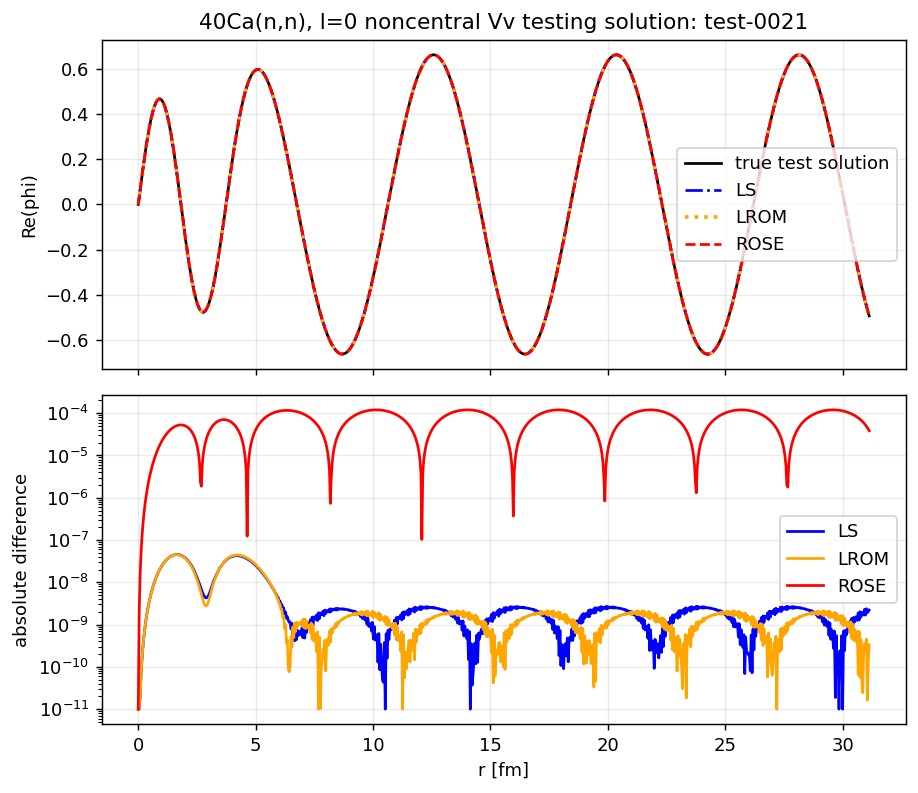

In [5]:
candidate_indices = np.flatnonzero(vv_plot_mask)
vv_representative_index = candidate_indices[len(candidate_indices) // 2]
vv_representative_id = vv_emulator.samples.design.testing.case_ids[vv_representative_index]
vv_case = vv_emulator.testing_case(case_id=vv_representative_id)
print("selected noncentral Vv testing case:", vv_representative_id, dict(vv_case.parameters))
print("distance from central Vv [MeV]:", abs(vv_case.parameters["Vv"] - Vv0))

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)
axes[0].plot(vv_case.radius, np.real(vv_case.high_fidelity[0]), color="black", label="true test solution")
axes[0].plot(vv_case.radius, np.real(vv_ls_wavefunctions[vv_representative_index]), "-.", color="blue", label="LS")
axes[0].plot(vv_case.radius, np.real(vv_case.lrom[0]), ":", color="orange", linewidth=2, label="LROM")
axes[0].plot(vv_case.radius, np.real(vv_rose_wavefunctions[vv_representative_index]), "--", color="red", label="ROSE")
axes[0].set_ylabel("Re(phi)")
axes[0].set_title(f"40Ca(n,n), l=0 noncentral Vv testing solution: {vv_representative_id}")
axes[0].legend()
axes[1].plot(vv_case.radius, np.maximum(np.abs(vv_case.high_fidelity[0] - vv_ls_wavefunctions[vv_representative_index]), DISPLAY_ERROR_FLOOR), color="blue", label="LS")
axes[1].plot(vv_case.radius, np.maximum(np.abs(vv_case.high_fidelity[0] - vv_case.lrom[0]), DISPLAY_ERROR_FLOOR), color="orange", label="LROM")
axes[1].plot(vv_case.radius, np.maximum(np.abs(vv_case.high_fidelity[0] - vv_rose_wavefunctions[vv_representative_index]), DISPLAY_ERROR_FLOOR), color="red", label="ROSE")
axes[1].set_yscale("log")
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel("absolute difference")
axes[1].legend()
fig.tight_layout()
plt.show()

Finally, the pointwise error family shows how each approximation
behaves across every noncentral Vv testing case.

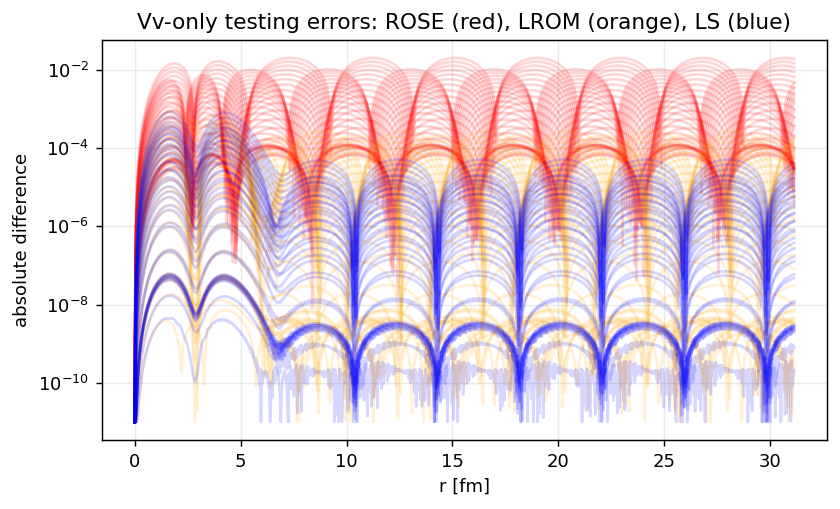

In [6]:
vv_errors = dict(vv_emulator.testing_errors[0])
vv_errors["ls"] = np.abs(vv_ls_wavefunctions - vv_fom_test)
vv_errors["rose"] = np.abs(vv_rose_wavefunctions - vv_fom_test)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for method, color in (("rose", "red"), ("lrom", "orange"), ("ls", "blue")):
    for error in vv_errors[method][vv_plot_mask]:
        ax.plot(r, np.maximum(error, DISPLAY_ERROR_FLOOR), color=color, alpha=0.16)
ax.set_yscale("log")
ax.set_xlabel("r [fm]")
ax.set_ylabel("absolute difference")
ax.set_title("Vv-only testing errors: ROSE (red), LROM (orange), LS (blue)")
plt.show()

## Section 2. Three-Parameter LROM Equation And Predictor Selection

The second object varies Vv, Rv, and av together. Its default potential
predictors are values of the Woods-Saxon potential at six physical radii
selected from the training ensemble by SVD and maxvol-style selection.

The transformed equation has the form
$(I + \sum_{j=1}^{K}p_j(\alpha)M_j)a(\alpha)
= \sum_{j=1}^{K}p_j(\alpha)b_j$, where $\alpha=(V_v,R_v,a_v)$
is the physical parameter vector. We first fit raw parameter predictors
as a diagnostic, then refit the same snapshots with potential predictors.
This tests the predictor choice without rerunning the FOM.
The constant source $b_0$ is identically zero here because the
predictors and the reduced coordinates are both centered on the
reference solution: $p = 0$ must give $a = 0$.

In [7]:
ws3_emulator = lrom.LROM(
    target=(40, 20),
    projectile=(1, 0),
    lab_energy=14.1,
    l=0,
    fom="nucl-scatter-eq",
    potential="ws_3",
)
ws3_center = dict(ws3_emulator.central_parameters)
ws3_training_ranges = {
    name: (0.90 * ws3_center[name], 1.10 * ws3_center[name])
    for name in ("Vv", "Rv", "av")
}
ws3_testing_ranges = {
    "Vv": (0.78 * ws3_center["Vv"], 1.22 * ws3_center["Vv"]),
    "Rv": (0.80 * ws3_center["Rv"], 1.20 * ws3_center["Rv"]),
    "av": (0.80 * ws3_center["av"], 1.20 * ws3_center["av"]),
}

# Public call: sample the three-parameter physical region once.
ws3_emulator.sampling(
    training_ranges=ws3_training_ranges,
    testing_ranges=ws3_testing_ranges,
    training_size=70,
    testing_size=81,
    mesh_size=800,
    strategy="latin_hypercube",
    seed=1204,
    high_fidelity_solver="runge_kutta",
)
# Diagnostic fit: preserve raw parameter predictors before retraining.
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="parameters",
    predictor_count=3,
)
parameter_lrom = np.asarray(
    ws3_emulator.testing_results.lrom[0]
).copy()
parameter_relative_l2 = np.asarray(
    ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
).copy()
parameter_training_relative_l2 = np.asarray(
    ws3_emulator.training_results.metrics["relative_l2"][0]["lrom"]
).copy()

# Main fit: reuse the same FOM snapshots with potential predictors.
ws3_emulator.train(
    basis_size=BASIS_SIZE,
    predictor="potential",
    predictor_count=6,
)

# Compute the optional LS basis floor explicitly for both sampled sets.
ws3_fom_train = ws3_emulator.samples.training_wavefunctions[0]
ws3_fom_test = ws3_emulator.samples.testing_wavefunctions[0]
ws3_ls_train_coefficients, ws3_ls_wf_train = lrom.least_squares_baseline(
    basis=ws3_emulator.basis[0],
    wavefunctions=ws3_fom_train,
)
ws3_ls_coefficients, ws3_ls_wf_test = lrom.least_squares_baseline(
    basis=ws3_emulator.basis[0],
    wavefunctions=ws3_fom_test,
)
ws3_ls_rel_train = lrom.relative_l2(
    prediction=ws3_ls_wf_train,
    reference=ws3_fom_train,
)
ws3_ls_rel_test = lrom.relative_l2(
    prediction=ws3_ls_wf_test,
    reference=ws3_fom_test,
)

# The ws_3 ROSE comparison owns a separate non-affine EIM over the
# central, training, and wider testing parameter region.
ws3_central_row = np.asarray(
    [ws3_center[name] for name in ws3_emulator.parameter_names]
)
ws3_rose_rows = np.vstack([
    ws3_central_row,
    ws3_emulator.samples.design.training.values,
    ws3_emulator.samples.design.testing.values,
])
ws3_rose_bounds = np.column_stack([
    ws3_rose_rows.min(axis=0),
    ws3_rose_rows.max(axis=0),
])
ws3_rose_interactions = rose.InteractionEIMSpace(
    l_max=0,
    coordinate_space_potential=rose_real_woods_saxon,
    n_theta=len(ws3_emulator.parameter_names),
    mu=ws3_emulator.kinematics.mu,
    energy=ws3_emulator.kinematics.e_com,
    is_complex=False,
    training_info=ws3_rose_bounds,
    n_basis=8,
    rho_mesh=ws3_emulator.samples.mesh.rho,
)
ws3_rose_interaction = ws3_rose_interactions.interactions[0][0]

# The ws_3 ROSE emulator uses the same free-reference construction.
ws3_rose_phi0 = np.asarray([
    rose.free_solutions.phi_free(float(rho), 0, ws3_emulator.kinematics.eta)
    for rho in ws3_emulator.samples.mesh.rho
], dtype=np.complex128)
ws3_rose_basis = rose.basis.CustomBasis(
    solutions=np.asarray(ws3_emulator.samples.training_wavefunctions[0], dtype=np.complex128).T.copy(),
    phi_0=ws3_rose_phi0.copy(),
    rho_mesh=ws3_emulator.samples.mesh.rho,
    n_basis=BASIS_SIZE,
    solver=ws3_emulator.full_order_model[0].solver,
    subtract_phi0=True,
    use_svd=True,
    center=False,
    scale=False,
)
ws3_rose_rbe = rose.reduced_basis_emulator.ReducedBasisEmulator(
    ws3_rose_interaction,
    ws3_rose_basis,
    s_0=ws3_emulator.full_order_model[0].base_solver.s_0,
    initialize_emulator=True,
)
ws3_train_rows = ws3_emulator.samples.design.training.values
ws3_test_rows = ws3_emulator.samples.design.testing.values
ws3_rose_coefficients = np.asarray([ws3_rose_rbe.coefficients(row) for row in ws3_test_rows])
ws3_rose_wf_train = np.asarray([ws3_rose_rbe.emulate_wave_function(row) for row in ws3_train_rows])
ws3_rose_wf_test = np.asarray([ws3_rose_rbe.emulate_wave_function(row) for row in ws3_test_rows])
ws3_rose_rel_train = np.linalg.norm(ws3_rose_wf_train - ws3_fom_train, axis=1) / np.linalg.norm(ws3_fom_train, axis=1)
ws3_rose_rel_test = np.linalg.norm(ws3_rose_wf_test - ws3_fom_test, axis=1) / np.linalg.norm(ws3_fom_test, axis=1)
ws3_rose_coefficient_norm = np.linalg.norm(ws3_rose_coefficients, ord=np.inf, axis=1)
ws3_rose_worst_indices = np.argsort(ws3_rose_coefficient_norm)[-3:][::-1]
print("worst corrected ROSE cases")
for index in ws3_rose_worst_indices:
    print({
        "case_id": ws3_emulator.samples.design.testing.case_ids[index],
        "parameters": ws3_emulator.samples.design.testing.named(index=index),
        "coefficient infinity norm": float(ws3_rose_coefficient_norm[index]),
        "relative L2 error": float(ws3_rose_rel_test[index]),
    })
print("potential predictor radii [fm]:", ws3_emulator.predictors.selected_radii)

worst corrected ROSE cases
{'case_id': 'test-0061', 'parameters': {'Vv': 38.595273757713834, 'Rv': 4.174092044596467, 'av': 0.7981966253136727}, 'coefficient infinity norm': 34.688654310176304, 'relative L2 error': 0.595242489530552}
{'case_id': 'test-0049', 'parameters': {'Vv': 38.1702406297923, 'Rv': 4.247865337430477, 'av': 0.7179589112403271}, 'coefficient infinity norm': 33.086899769684955, 'relative L2 error': 0.2438848580352921}
{'case_id': 'test-0019', 'parameters': {'Vv': 40.90517252268518, 'Rv': 3.878956116793021, 'av': 0.7512442146666718}, 'coefficient infinity norm': 32.63767505101002, 'relative L2 error': 0.23027662289531203}
potential predictor radii [fm]: [0.23377848 4.13008625 3.31186162 4.98727396 2.25985852 6.15616629]


The three pairwise panels show that $V_v$, $R_v$, and $a_v$ vary
together. In particular, the av variation is visible both as an axis
and as a color scale rather than being left implicit in the sample table.

The error summary then compares raw parameter predictors with the main
potential predictors on the same stored high-fidelity samples.

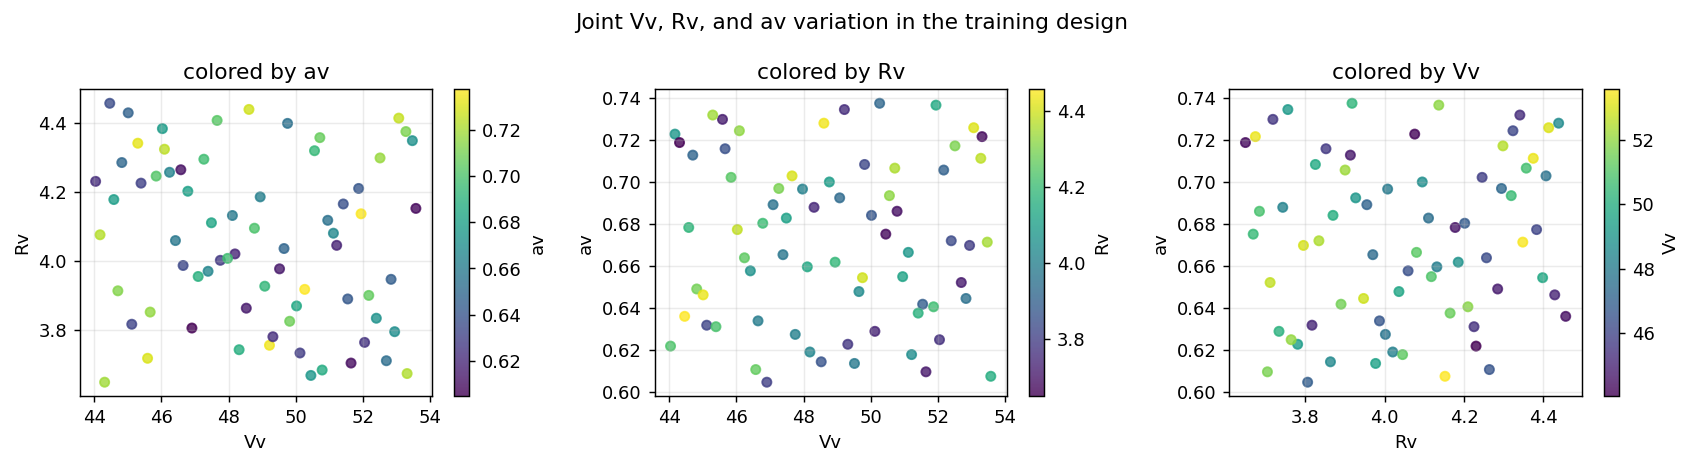

,testing median relative L2,testing maximum relative L2
predictors,,
raw parameters,0.007537,0.070258
potential values,0.005331,0.025802


In [8]:
ws3_names = ws3_emulator.parameter_names
ws3_training_rows = ws3_emulator.samples.design.training.values
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.6))
pairings = ((0, 1, 2), (0, 2, 1), (1, 2, 0))
for ax, (x_index, y_index, color_index) in zip(axes, pairings):
    scatter = ax.scatter(
        ws3_training_rows[:, x_index],
        ws3_training_rows[:, y_index],
        c=ws3_training_rows[:, color_index],
        cmap="viridis",
        s=26,
        alpha=0.8,
    )
    ax.set(
        xlabel=f"{ws3_names[x_index]}",
        ylabel=f"{ws3_names[y_index]}",
        title=f"colored by {ws3_names[color_index]}",
    )
    fig.colorbar(
        scatter,
        ax=ax,
        label=f"{ws3_names[color_index]}",
    )
fig.suptitle("Joint Vv, Rv, and av variation in the training design")
fig.tight_layout()
plt.show()

potential_relative_l2 = np.asarray(
    ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
)
pd.DataFrame([
    {
        "predictors": "raw parameters",
        "testing median relative L2": float(np.median(parameter_relative_l2)),
        "testing maximum relative L2": float(np.max(parameter_relative_l2)),
    },
    {
        "predictors": "potential values",
        "testing median relative L2": float(np.median(potential_relative_l2)),
        "testing maximum relative L2": float(np.max(potential_relative_l2)),
    },
]).set_index("predictors")

The potential ensemble is compressed separately from the wavefunctions.
Red markers identify the six physical radii selected for the potential
predictors, and the adjacent spectrum shows the ensemble decay.

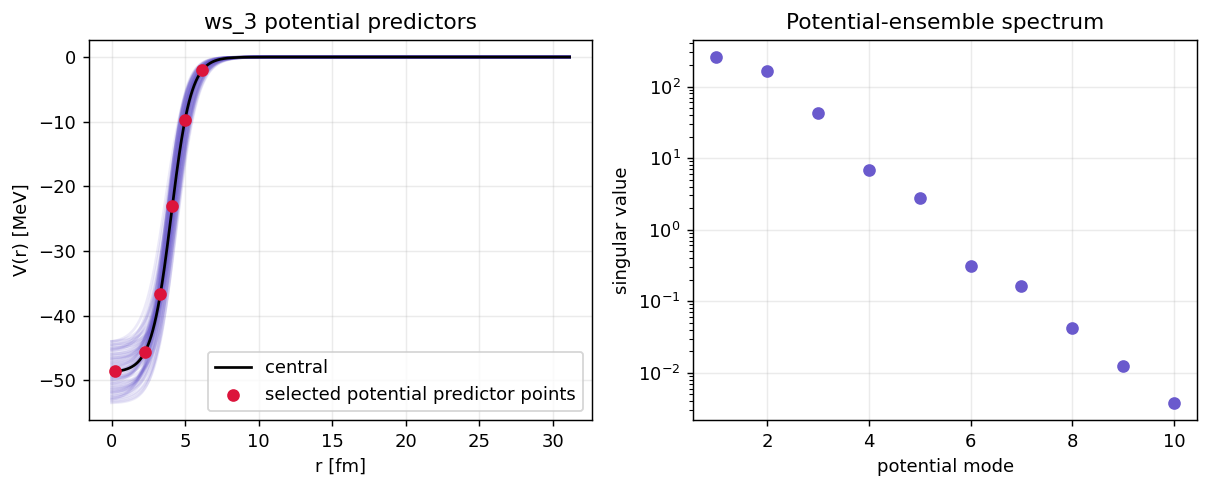

In [9]:
r3 = ws3_emulator.mesh.radius
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for potential in ws3_emulator.samples.training_potentials:
    axes[0].plot(r3, np.real(potential), color="slateblue", alpha=0.12)
axes[0].plot(r3, np.real(ws3_emulator.samples.central_potential), color="black", label="central")
selected_radii = ws3_emulator.predictors.selected_radii
selected_values = ws3_emulator.samples.central_potential[
    ws3_emulator.predictors.selected_indices
]
axes[0].scatter(
    selected_radii,
    np.real(selected_values),
    color="crimson",
    zorder=5,
    label="selected potential predictor points",
)
axes[0].set(xlabel="r [fm]", ylabel="V(r) [MeV]", title="ws_3 potential predictors")
axes[0].legend()

for index, singular_value in enumerate(ws3_emulator.predictors.singular_values[:10], start=1):
    axes[1].semilogy(index, singular_value, "o", color="slateblue")
axes[1].set(xlabel="potential mode", ylabel="singular value", title="Potential-ensemble spectrum")
plt.show()

The LROM and ROSE wavefunction bases again appear beside their
singular-value spectra. The following coefficient panels replace an
arbitrary case index with physical parameters: the horizontal axis is
$V_v$, while a second parameter supplies the color scale.

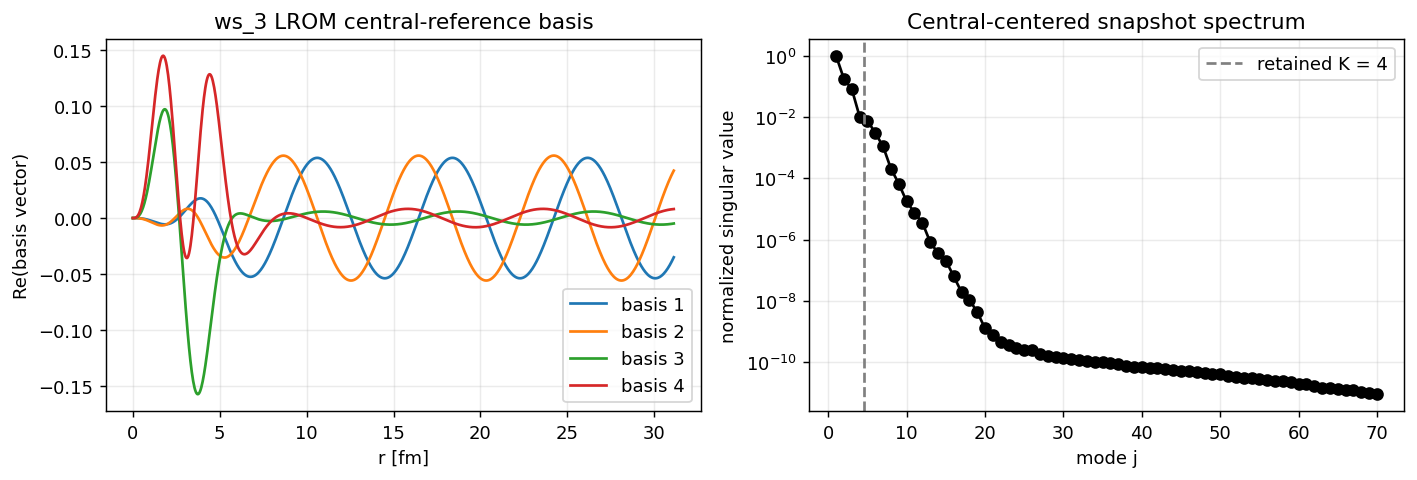

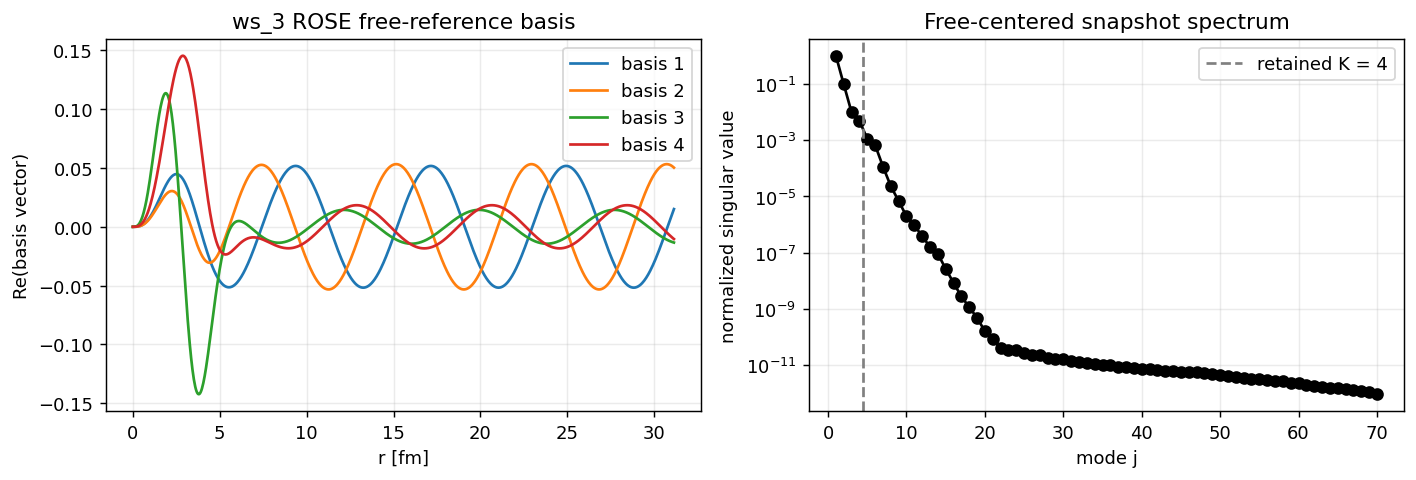

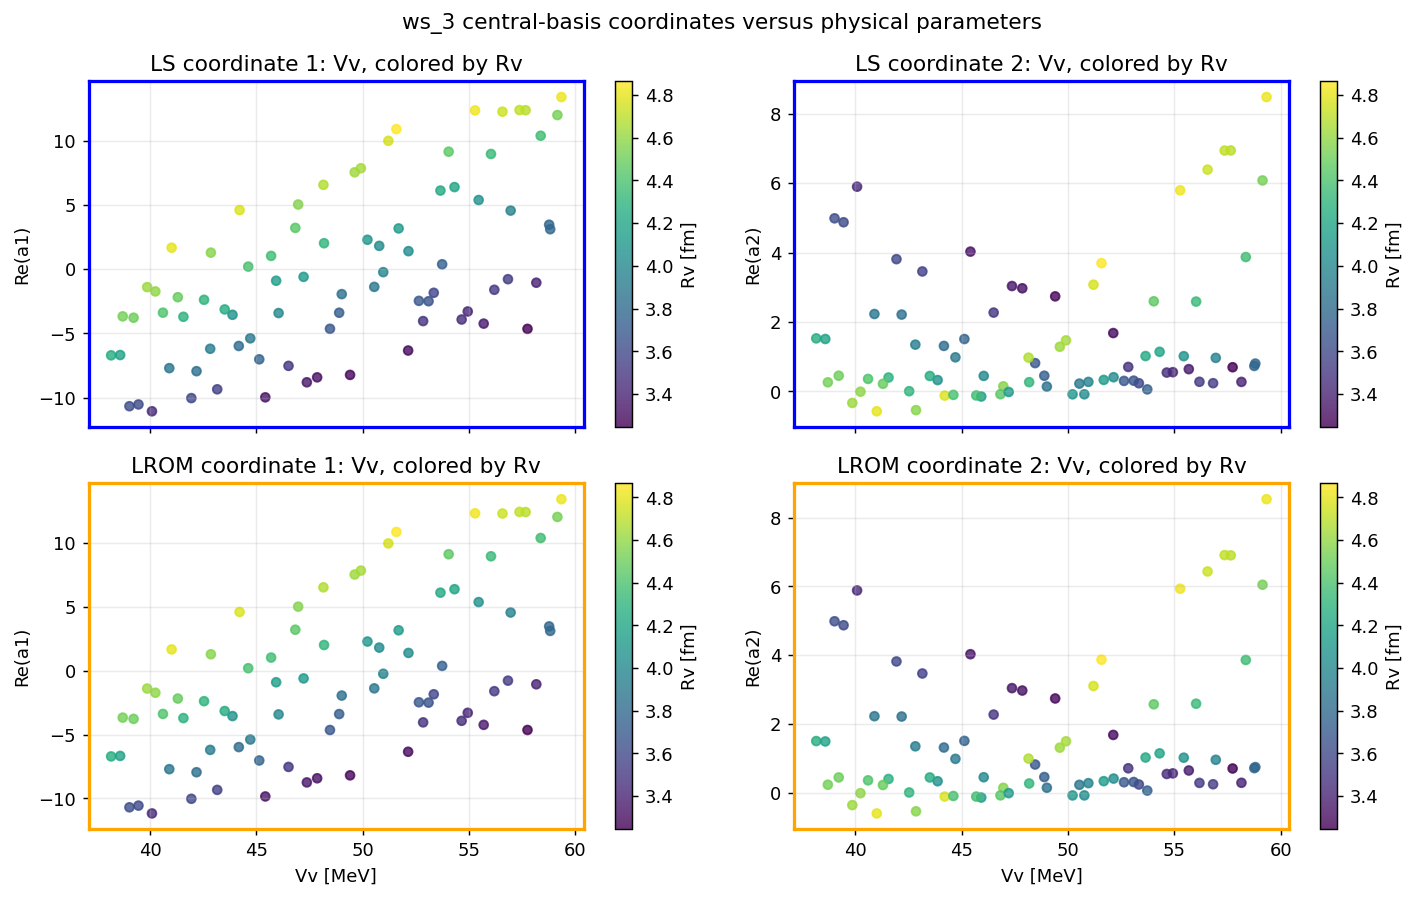

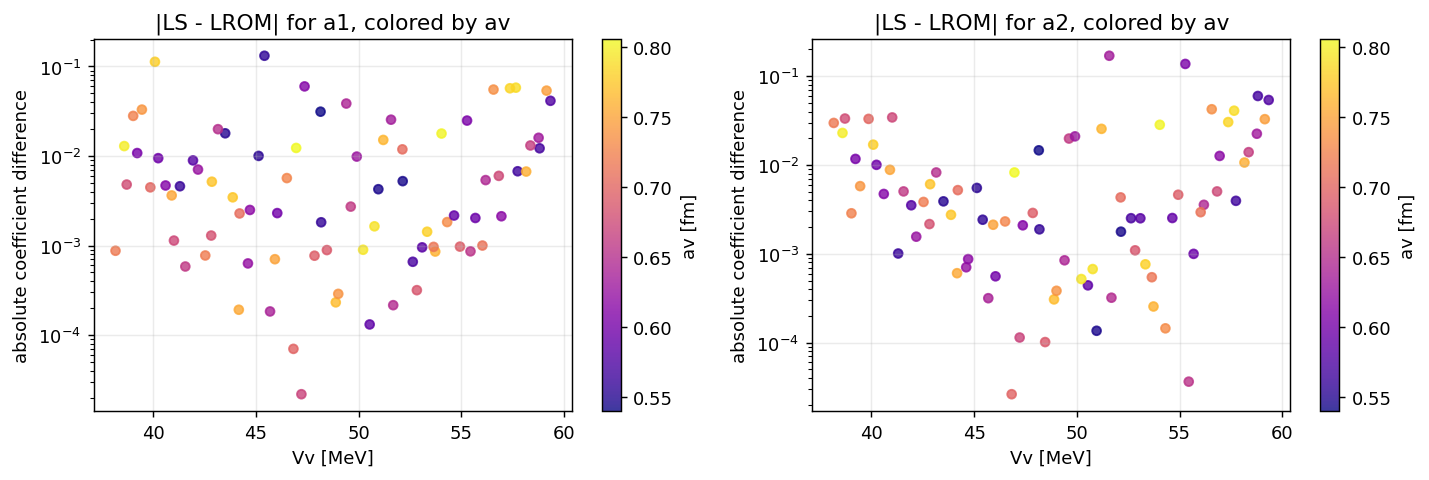

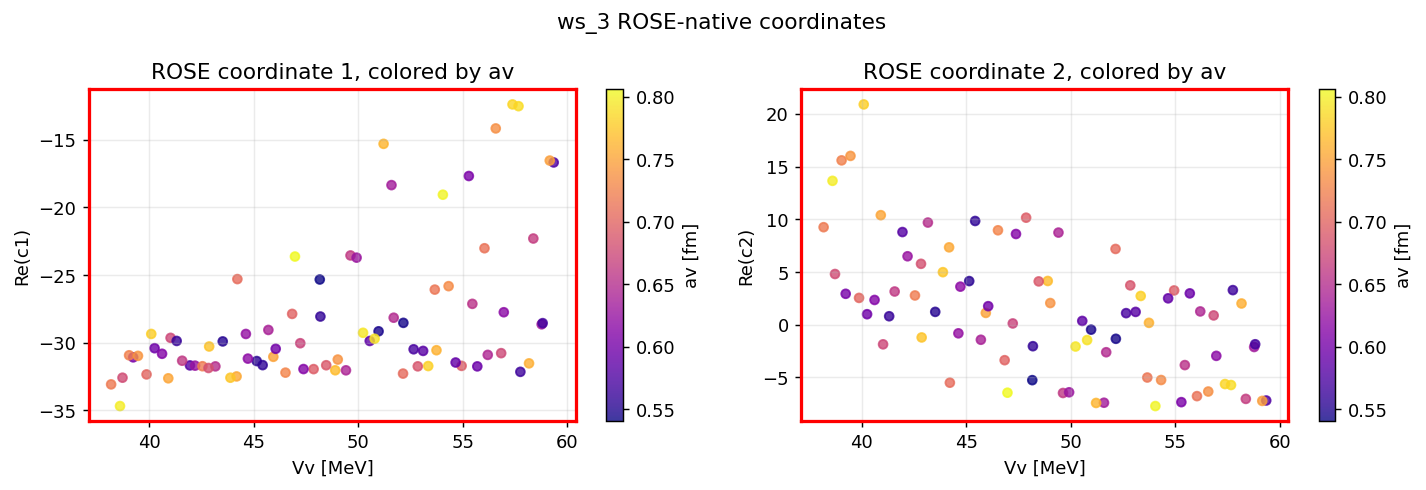

In [10]:
ws3_basis = ws3_emulator.basis[0]
ws3_lrom_centered_snapshots = (
    ws3_emulator.samples.training_wavefunctions[0]
    - ws3_emulator.samples.central_wavefunctions[0][None, :]
)
ws3_lrom_singular_values = np.linalg.svd(
    ws3_lrom_centered_snapshots, compute_uv=False
)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
for index in range(BASIS_SIZE):
    axes[0].plot(
        r3,
        np.real(ws3_basis.vectors[:, index]),
        label=f"basis {index + 1}",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="ws_3 LROM central-reference basis",
)
axes[0].legend()
ws3_lrom_normalized_singular_values = (
    ws3_lrom_singular_values / ws3_lrom_singular_values[0]
)
ws3_lrom_modes = np.arange(1, len(ws3_lrom_normalized_singular_values) + 1)
axes[1].plot(
    ws3_lrom_modes,
    ws3_lrom_normalized_singular_values,
    "o-",
    color="black",
)
axes[1].axvline(
    BASIS_SIZE + 0.5,
    color="gray",
    linestyle="--",
    label="retained K = 4",
)
axes[1].set_yscale("log")
axes[1].set(
    xlabel="mode j",
    ylabel="normalized singular value",
    title="Central-centered snapshot spectrum",
)
axes[1].legend()
fig.tight_layout()
plt.show()

ws3_rose_singular_values = np.asarray(ws3_rose_basis.singular_values)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8))
for index in range(BASIS_SIZE):
    axes[0].plot(
        r3,
        np.real(ws3_rose_basis.vectors[:, index]),
        label=f"basis {index + 1}",
    )
axes[0].set(
    xlabel="r [fm]",
    ylabel="Re(basis vector)",
    title="ws_3 ROSE free-reference basis",
)
axes[0].legend()
ws3_rose_normalized_singular_values = (
    ws3_rose_singular_values / ws3_rose_singular_values[0]
)
ws3_rose_modes = np.arange(1, len(ws3_rose_normalized_singular_values) + 1)
axes[1].plot(
    ws3_rose_modes,
    ws3_rose_normalized_singular_values,
    "o-",
    color="black",
)
axes[1].axvline(
    BASIS_SIZE + 0.5,
    color="gray",
    linestyle="--",
    label="retained K = 4",
)
axes[1].set_yscale("log")
axes[1].set(
    xlabel="mode j",
    ylabel="normalized singular value",
    title="Free-centered snapshot spectrum",
)
axes[1].legend()
fig.tight_layout()
plt.show()

coefficients = {
    "ls": {0: ws3_ls_coefficients},
    "lrom": dict(ws3_emulator.testing_results.coefficients["lrom"]),
}
ws3_lrom_coefficients = coefficients["lrom"][0]
fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.0), sharex=True)
for row_index, (method, method_color) in enumerate(
    (("ls", "blue"), ("lrom", "orange"))
):
    for coefficient_index, ax in enumerate(axes[row_index]):
        scatter = ax.scatter(
            ws3_test_rows[:, 0],
            np.real(coefficients[method][0][:, coefficient_index]),
            c=ws3_test_rows[:, 1],
            cmap="viridis",
            s=24,
            alpha=0.8,
        )
        for spine in ax.spines.values():
            spine.set_color(method_color)
            spine.set_linewidth(1.8)
        ax.set(
            ylabel=f"Re(a{coefficient_index + 1})",
            title=(
                f"{method.upper()} coordinate {coefficient_index + 1}: "
                "Vv, colored by Rv"
            ),
        )
        fig.colorbar(scatter, ax=ax, label="Rv [fm]")
for ax in axes[-1]:
    ax.set_xlabel("Vv [MeV]")
fig.suptitle("ws_3 central-basis coordinates versus physical parameters")
fig.tight_layout()
plt.show()

ws3_coordinate_difference = np.abs(
    ws3_ls_coefficients - ws3_lrom_coefficients
)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8), sharex=True)
for coefficient_index, ax in enumerate(axes):
    scatter = ax.scatter(
        ws3_test_rows[:, 0],
        np.maximum(
            ws3_coordinate_difference[:, coefficient_index],
            DISPLAY_ERROR_FLOOR,
        ),
        c=ws3_test_rows[:, 2],
        cmap="plasma",
        s=24,
        alpha=0.8,
    )
    ax.set_yscale("log")
    ax.set(
        xlabel="Vv [MeV]",
        ylabel="absolute coefficient difference",
        title=f"|LS - LROM| for a{coefficient_index + 1}, colored by av",
    )
    fig.colorbar(scatter, ax=ax, label="av [fm]")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.8), sharex=True)
for coefficient_index, ax in enumerate(axes):
    scatter = ax.scatter(
        ws3_test_rows[:, 0],
        np.real(ws3_rose_coefficients[:, coefficient_index]),
        c=ws3_test_rows[:, 2],
        cmap="plasma",
        s=24,
        alpha=0.8,
    )
    for spine in ax.spines.values():
        spine.set_color("red")
        spine.set_linewidth(1.8)
    ax.set(
        xlabel="Vv [MeV]",
        ylabel=f"Re(c{coefficient_index + 1})",
        title=f"ROSE coordinate {coefficient_index + 1}, colored by av",
    )
    fig.colorbar(scatter, ax=ax, label="av [fm]")
fig.suptitle("ws_3 ROSE-native coordinates")
fig.tight_layout()
plt.show()

## Section 3. Three-Parameter Wavefunction Emulation Results

We now inspect one representative testing solution and compare the
training and testing relative-error distributions. The least-squares
curve is the attainable floor for this fixed basis.

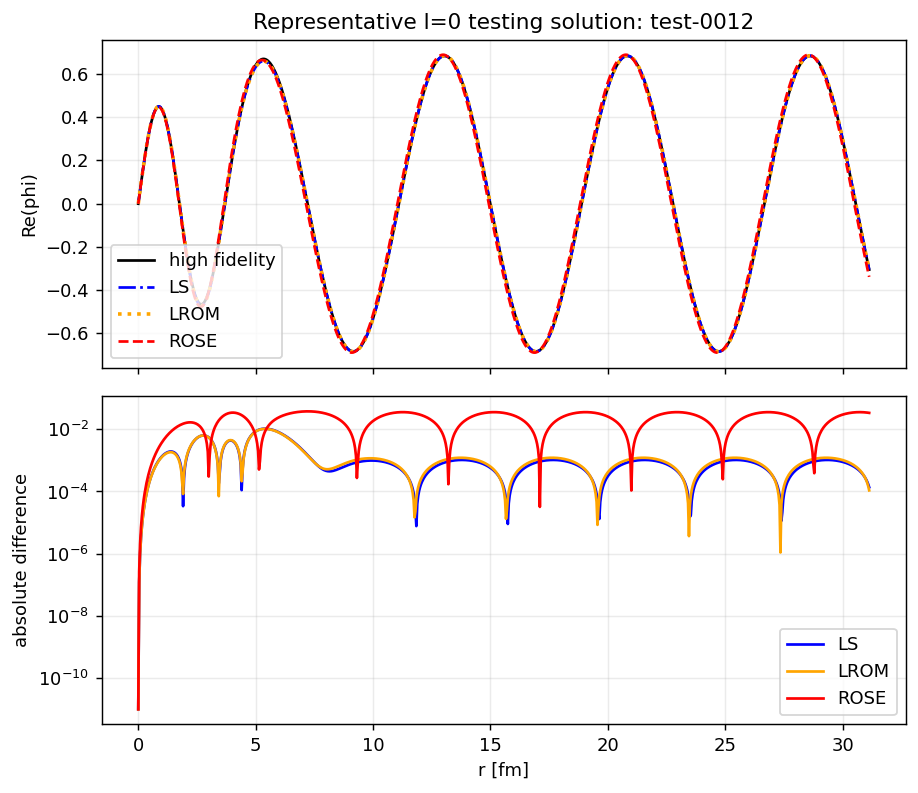

In [11]:
lrom_relative = ws3_emulator.testing_results.metrics["relative_l2"][0]["lrom"]
representative_index = int(np.argsort(lrom_relative)[len(lrom_relative) // 2])
representative_id = ws3_emulator.samples.design.testing.case_ids[representative_index]
case = ws3_emulator.testing_case(case_id=representative_id)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2), sharex=True)
axes[0].plot(case.radius, np.real(case.high_fidelity[0]), color="black", label="high fidelity")
axes[0].plot(case.radius, np.real(ws3_ls_wf_test[representative_index]), "-.", color="blue", label="LS")
axes[0].plot(case.radius, np.real(case.lrom[0]), ":", color="orange", linewidth=2, label="LROM")
axes[0].plot(case.radius, np.real(ws3_rose_wf_test[representative_index]), "--", color="red", label="ROSE")
axes[0].set_ylabel("Re(phi)")
axes[0].set_title(f"Representative l=0 testing solution: {representative_id}")
axes[0].legend()
axes[1].plot(case.radius, np.maximum(np.abs(case.high_fidelity[0] - ws3_ls_wf_test[representative_index]), DISPLAY_ERROR_FLOOR), color="blue", label="LS")
axes[1].plot(case.radius, np.maximum(np.abs(case.high_fidelity[0] - case.lrom[0]), DISPLAY_ERROR_FLOOR), color="orange", label="LROM")
axes[1].plot(case.radius, np.maximum(np.abs(case.high_fidelity[0] - ws3_rose_wf_test[representative_index]), DISPLAY_ERROR_FLOOR), color="red", label="ROSE")
axes[1].set_yscale("log")
axes[1].set_xlabel("r [fm]")
axes[1].set_ylabel("absolute difference")
axes[1].legend()
fig.tight_layout()
plt.show()

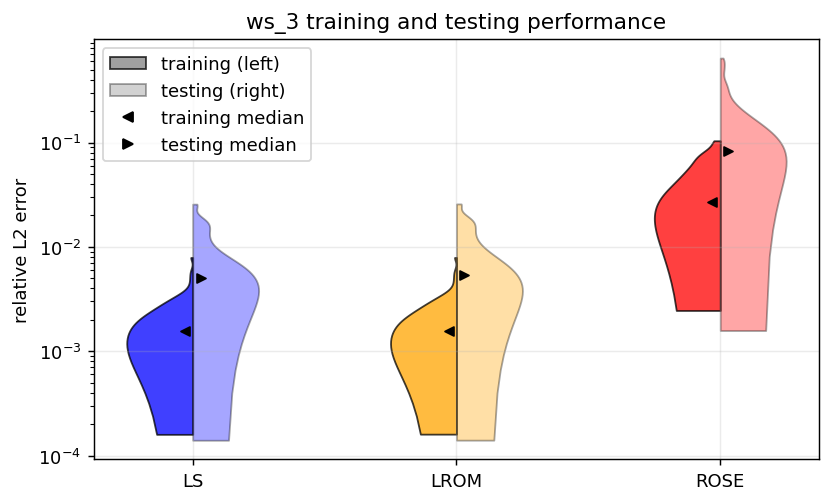

In [12]:
methods = ("ls", "lrom", "rose")
colors = ("blue", "orange", "red")
positions = np.arange(1, 4)
training_metrics = dict(ws3_emulator.training_results.metrics["relative_l2"][0])
training_metrics["ls"] = ws3_ls_rel_train
training_metrics["rose"] = ws3_rose_rel_train
testing_metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
testing_metrics["ls"] = ws3_ls_rel_test
testing_metrics["rose"] = ws3_rose_rel_test
training_values = [
    np.maximum(training_metrics[method], np.finfo(float).tiny)
    for method in methods
]
testing_values = [
    np.maximum(testing_metrics[method], np.finfo(float).tiny)
    for method in methods
]
fig, ax = plt.subplots(figsize=(7.2, 4.2))
training_violin = ax.violinplot(
    training_values,
    positions=positions,
    showextrema=False,
)
testing_violin = ax.violinplot(
    testing_values,
    positions=positions,
    showextrema=False,
)
for center, body, color in zip(positions, training_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.minimum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.75)
for center, body, color in zip(positions, testing_violin["bodies"], colors):
    vertices = body.get_paths()[0].vertices
    vertices[:, 0] = np.maximum(vertices[:, 0], center)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_alpha(0.35)
ax.scatter(positions - 0.03, [np.median(values) for values in training_values], color="black", marker="<", s=24)
ax.scatter(positions + 0.03, [np.median(values) for values in testing_values], color="black", marker=">", s=24)
ax.set_xticks(positions, [method.upper() for method in methods])
ax.set_yscale("log")
ax.set_ylabel("relative L2 error")
ax.set_title("ws_3 training and testing performance")
ax.legend(handles=[
    Patch(facecolor="gray", edgecolor="black", alpha=0.75, label="training (left)"),
    Patch(facecolor="gray", edgecolor="black", alpha=0.35, label="testing (right)"),
    Line2D([], [], color="black", marker="<", linestyle="None", label="training median"),
    Line2D([], [], color="black", marker=">", linestyle="None", label="testing median"),
])
plt.show()

In [13]:
test_values = ws3_emulator.samples.design.testing.values
names = ws3_emulator.parameter_names
interpolation = np.ones(len(test_values), dtype=bool)
for column, name in enumerate(names):
    low, high = ws3_training_ranges[name]
    interpolation &= (test_values[:, column] >= low) & (test_values[:, column] <= high)

rows = []
metrics = dict(ws3_emulator.testing_results.metrics["relative_l2"][0])
metrics["ls"] = ws3_ls_rel_test
metrics["rose"] = ws3_rose_rel_test
for region, mask in (("interpolation", interpolation), ("extrapolation", ~interpolation)):
    for method in ("rose", "lrom", "ls"):
        values = metrics[method][mask]
        rows.append(
            {
                "region": region,
                "method": method.upper(),
                "cases": int(mask.sum()),
                "median relative L2": float(np.median(values)),
                "maximum relative L2": float(np.max(values)),
            }
        )
pd.DataFrame(rows).set_index(["region", "method"])

cases  median relative L2  maximum relative L2
region        method                                                
interpolation ROSE        9            0.028559             0.096253
              LROM        9            0.001462             0.003065
              LS          9            0.001449             0.003064
extrapolation ROSE       72            0.094632             0.644172
              LROM       72            0.005726             0.025802
              LS         72            0.005419             0.025691

In [14]:
artifact_path = ROOT / "outputs" / "notebook01_ws3_model.lrom"
ws3_emulator.save(path=artifact_path)
portable_emulator = lrom.load(path=artifact_path)
portable_emulator.predict(parameters=case.parameters)
print("portable model:", artifact_path)
print("prediction shape:", portable_emulator.predictions.wavefunctions[0].shape)

portable model: /Users/Kitkat/Documents/Documents-Agent/LROM_Project/outputs/notebook01_ws3_model.lrom
prediction shape: (1, 800)
